# Task 3

## Objective
It aims to analyze the Titanic dataset to uncover patterns affecting passenger survival using Python and pandas and also it involves creating a custom dataset.

# Part 1: Creating a Custom Dataset

In this part, we create our own dataset using a Python dictionary.  
The dataset contains 5 features and 15 records with a custom index.

**Step 1: Importing Required Library**

We use pandas for data manipulation and analysis.

In [30]:
import pandas as pd

### Part 1: Creating a Custom Dataset

We create a dataset with 5 columns and 15 rows using a dictionary and assign a custom index.

### Step 1: Creating the Dataset

In [31]:
data = {
    "Name": ["A", "B", "C", "D", "E", "F", "G", "H", "I", "J", "K", "L", "M", "N", "O"],
    "Age": [22, 25, 30, 28, 35, 40, 23, 27, 29, 31, 26, 34, 32, 24, 33],
    "Department": ["IT", "HR", "IT", "Finance", "HR", "IT", "Finance", "IT", "HR", "Finance", "IT", "HR", "Finance", "IT", "HR"],
    "Salary": [500, 600, 700, 650, 620, 800, 720, 710, 690, 730, 750, 680, 770, 760, 740],
    "Experience": [1, 2, 5, 4, 6, 10, 3, 2, 4, 5, 6, 7, 8, 3, 4]
}

### Step 2: Creating Custom Index

In [32]:
index_labels = [f"EMP_{i}" for i in range(1, 16)]

### Step 3: Creating DataFrame

In [33]:
df_custom = pd.DataFrame(data, index=index_labels)

### Step 4: Viewing the Dataset

In [34]:
df_custom

,Name,Age,Department,Salary,Experience
EMP_1,A,22,IT,500,1
EMP_2,B,25,HR,600,2
EMP_3,C,30,IT,700,5
EMP_4,D,28,Finance,650,4
EMP_5,E,35,HR,620,6
EMP_6,F,40,IT,800,10
EMP_7,G,23,Finance,720,3
EMP_8,H,27,IT,710,2
EMP_9,I,29,HR,690,4
EMP_10,J,31,Finance,730,5


#  Part 2: Titanic Dataset Analysis
We analyze a real dataset to extract meaningful insights.

## Step 1: Loading Dataset
Upload the Titanic dataset (train.csv).

In [35]:
import pandas as pd

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

##  Step 2: Data Exploration

### Preview of Dataset

In [36]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Dataset Information

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


### Statistical Summary

In [38]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


##  Step 3: Data Cleaning
We handle missing values and remove unnecessary data.

### Handling Missing Values (Age → Median)

In [39]:
df["Age"] = df["Age"].fillna(df["Age"].median())

### Handling Missing Values (Embarked → Mode)

In [40]:
df["Embarked"].fillna(df["Embarked"].mode()[0])

,Embarked
0,S
1,C
2,S
3,S
4,S
...,...
886,S
887,S
888,S
889,C


### Dropping Cabin Column

In [41]:
df.drop(columns=["Cabin"], inplace=True)

## Step 4: Data Analysis
Using groupby() to analyze patterns.

### Survival Rate by Gender

In [42]:
df.groupby("Sex")["Survived"].mean()

,Survived
Sex,
female,0.742038
male,0.188908


### Survival Rate by Class

In [43]:
df.groupby("Pclass")["Survived"].mean()

,Survived
Pclass,
1,0.629630
2,0.472826
3,0.242363


### Survival Rate by Age Group

In [50]:
df["AgeGroup"] = pd.cut(df["Age"], bins=[0, 12, 18, 60, 100], labels=["Child", "Teen", "Adult", "Senior"])
df.groupby("AgeGroup")["Survived"].mean()

/tmp/ipykernel_9485/3904456696.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("AgeGroup")["Survived"].mean()


,Survived
AgeGroup,
Child,0.579710
Teen,0.428571
Adult,0.365753
Senior,0.227273


## 🔎 Step 5: Data Filtering

In [45]:
df[(df["Sex"] == "female") & (df["Survived"] == 1)]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,AgeGroup
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,Adult
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,Adult
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,Adult
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,S,Adult
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,C,Teen
...,...,...,...,...,...,...,...,...,...,...,...,...
874,875,1,2,"Abelson, Mrs. Samuel (Hannah Wizosky)",female,28.0,1,0,P/PP 3381,24.0000,C,Adult
875,876,1,3,"Najib, Miss. Adele Kiamie ""Jane""",female,15.0,0,0,2667,7.2250,C,Teen
879,880,1,1,"Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)",female,56.0,0,1,11767,83.1583,C,Adult
880,881,1,2,"Shelley, Mrs. William (Imanita Parrish Hall)",female,25.0,0,1,230433,26.0000,S,Adult


### Children Who Survived

In [46]:
df[(df["Age"] < 12) & (df["Survived"] == 1)]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,AgeGroup
10,11,1,3,"Sandstrom, Miss. Marguerite Rut",female,4.00,1,1,PP 9549,16.7000,S,Child
43,44,1,2,"Laroche, Miss. Simonne Marie Anne Andree",female,3.00,1,2,SC/Paris 2123,41.5792,C,Child
58,59,1,2,"West, Miss. Constance Mirium",female,5.00,1,2,C.A. 34651,27.7500,S,Child
78,79,1,2,"Caldwell, Master. Alden Gates",male,0.83,0,2,248738,29.0000,S,Child
165,166,1,3,"Goldsmith, Master. Frank John William ""Frankie""",male,9.00,0,2,363291,20.5250,S,Child
172,173,1,3,"Johnson, Miss. Eleanor Ileen",female,1.00,1,1,347742,11.1333,S,Child
183,184,1,2,"Becker, Master. Richard F",male,1.00,2,1,230136,39.0000,S,Child
184,185,1,3,"Kink-Heilmann, Miss. Luise Gretchen",female,4.00,0,2,315153,22.0250,S,Child
193,194,1,2,"Navratil, Master. Michel M",male,3.00,1,1,230080,26.0000,S,Child
233,234,1,3,"Asplund, Miss. Lillian Gertrud",female,5.00,4,2,347077,31.3875,S,Child


### First-Class Passengers

In [47]:
df[df["Pclass"] == 1]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,AgeGroup
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,Adult
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,Adult
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,S,Adult
11,12,1,1,"Bonnell, Miss. Elizabeth",female,58.0,0,0,113783,26.5500,S,Adult
23,24,1,1,"Sloper, Mr. William Thompson",male,28.0,0,0,113788,35.5000,S,Adult
...,...,...,...,...,...,...,...,...,...,...,...,...
871,872,1,1,"Beckwith, Mrs. Richard Leonard (Sallie Monypeny)",female,47.0,1,1,11751,52.5542,S,Adult
872,873,0,1,"Carlsson, Mr. Frans Olof",male,33.0,0,0,695,5.0000,S,Adult
879,880,1,1,"Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)",female,56.0,0,1,11767,83.1583,C,Adult
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S,Adult


##  Step 6: Key Insights

- Females were more likely to survive than males  
- First-class passengers had higher survival rates  
- Children were prioritized during rescue  
- Female passengers in first class had the highest survival probability  

## Visualization (Optional)

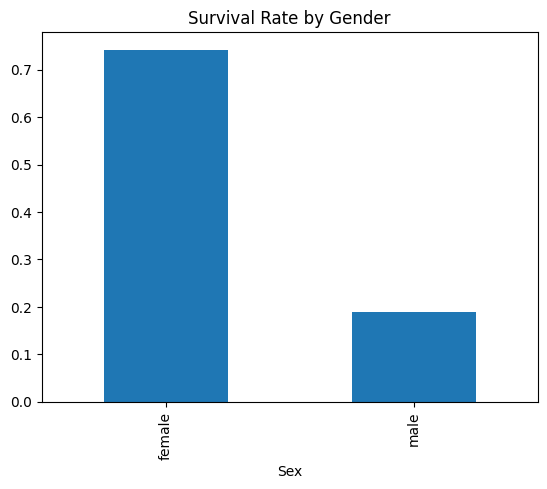

In [48]:
import matplotlib.pyplot as plt

df.groupby("Sex")["Survived"].mean().plot(kind="bar")
plt.title("Survival Rate by Gender")
plt.show()

##  Conclusion

This project demonstrates how data analysis can reveal patterns and insights using pandas.